In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Funtzioa karpeta bat prozesatzeko
def prozesatu_karpeta(oinarri_karpeta):
    datuak = []
    
    # Subkarpetak begiratu
    for azpikarpetak in os.listdir(oinarri_karpeta):
        azpikarpetaren_bidea = os.path.join(oinarri_karpeta, azpikarpetak)
        if os.path.isdir(azpikarpetaren_bidea) and azpikarpetak.isdigit(): # Urte izeneko karpetak bakarrik
            txt_fitxategiak = [f for f in os.listdir(azpikarpetaren_bidea) if f.endswith('.txt')]
            hitzaldi_kop = len(txt_fitxategiak)
            hitz_totalak = 0
            
            for fitxategia in txt_fitxategiak:
                fitx_bidea = os.path.join(azpikarpetaren_bidea, fitxategia)
                with open(fitx_bidea, 'r', encoding='utf-8') as f:
                    testua = f.read()
                    hitzak = testua.split() # Tokenizazioa hutsunez
                    hitz_totalak += len(hitzak)
            
            datuak.append({
                "Urtea": int(azpikarpetak),
                "Hitzaldiak": hitzaldi_kop,
                "Hitzak_Guztira": hitz_totalak
            })
    
    df = pd.DataFrame(datuak)
    df["Hitz_Media"] = df["Hitzak_Guztira"] / df["Hitzaldiak"]
    return df

In [3]:
# Dataset-en karpeten bideak
base_dir_basqueParl = "basque-parliament-corpus-transcriptions"
base_dir_parlaMint = "ParlaMint-ES-PV"

# Bi datasetak prozesatu
df_basqueParl = prozesatu_karpeta(base_dir_basqueParl)
df_parlaMint = prozesatu_karpeta(base_dir_parlaMint)

# Urteka ordenatu
df_basqueParl = df_basqueParl.sort_values("Urtea").reset_index(drop=True)
df_parlaMint  = df_parlaMint.sort_values("Urtea").reset_index(drop=True)

# Emaitzak erakutsi
print("BasqueParl:")
print(df_basqueParl)

print("\nParlaMint:")
print(df_parlaMint)


BasqueParl:
   Urtea  Hitzaldiak  Hitzak_Guztira  Hitz_Media
0   2012           2            1322      661.00
1   2013           2           80283    40141.50
2   2014           2           87502    43751.00
3   2015           2           87428    43714.00
4   2016           0               0         NaN
5   2017           0               0         NaN
6   2018          12          522783    43565.25
7   2019          48         2029644    42284.25
8   2020           2           90530    45265.00

ParlaMint:
   Urtea  Hitzaldiak  Hitzak_Guztira    Hitz_Media
0   2015          43         1724990  40116.046512
1   2016          35         1336493  38185.514286
2   2017          51         2096503  41107.901961
3   2018          48         2005678  41784.958333
4   2019          48         1960622  40846.291667
5   2020          27          936228  34675.111111
6   2021          49         2040309  41638.959184
7   2022          37         1502874  40618.216216


In [4]:
# Guztira globalak (beharrezkoa izanez gero)
totala_basqueParl = {
    "Hitzaldiak_Guztira": int(df_basqueParl["Hitzaldiak"].sum()),
    "Hitzak_Guztira_Global": int(df_basqueParl["Hitzak_Guztira"].sum()),
    "Hitz_Media_Globala": float(round(df_basqueParl["Hitzak_Guztira"].sum() / df_basqueParl["Hitzaldiak"].sum(), 2))
}

totala_parlaMint = {
    "Hitzaldiak_Guztira": int(df_parlaMint["Hitzaldiak"].sum()),
    "Hitzak_Guztira_Global": int(df_parlaMint["Hitzak_Guztira"].sum()),
    "Hitz_Media_Globala": float(round(df_parlaMint["Hitzak_Guztira"].sum() / df_parlaMint["Hitzaldiak"].sum(), 2))
}

print("\nTotala BasqueParl:")
print(totala_basqueParl)

print("\nTotala ParlaMint:")
print(totala_parlaMint)


Totala BasqueParl:
{'Hitzaldiak_Guztira': 70, 'Hitzak_Guztira_Global': 2899492, 'Hitz_Media_Globala': 41421.31}

Totala ParlaMint:
{'Hitzaldiak_Guztira': 338, 'Hitzak_Guztira_Global': 13603697, 'Hitz_Media_Globala': 40247.62}


In [5]:
df_BP = pd.read_csv("global-BasqueParl.tsv", sep = "\t")
hizlariak = df_BP["Speaker"].nunique()
print(f"{hizlariak} hizlari desberdin daude BasqueParl-en.")


179 hizlari desberdin daude BasqueParl-en.


In [6]:
df_PM = pd.read_csv("global-ParlaMint-ES-PV.tsv", sep = "\t")
hizlariak = df_PM["Speaker"].nunique()
print(f"{hizlariak} hizlari desberdin daude ParlaMint-ES-PV-n.")

175 hizlari desberdin daude ParlaMint-ES-PV-n.


In [7]:
years = sorted(set(df_basqueParl["Urtea"]).union(df_parlaMint["Urtea"]))


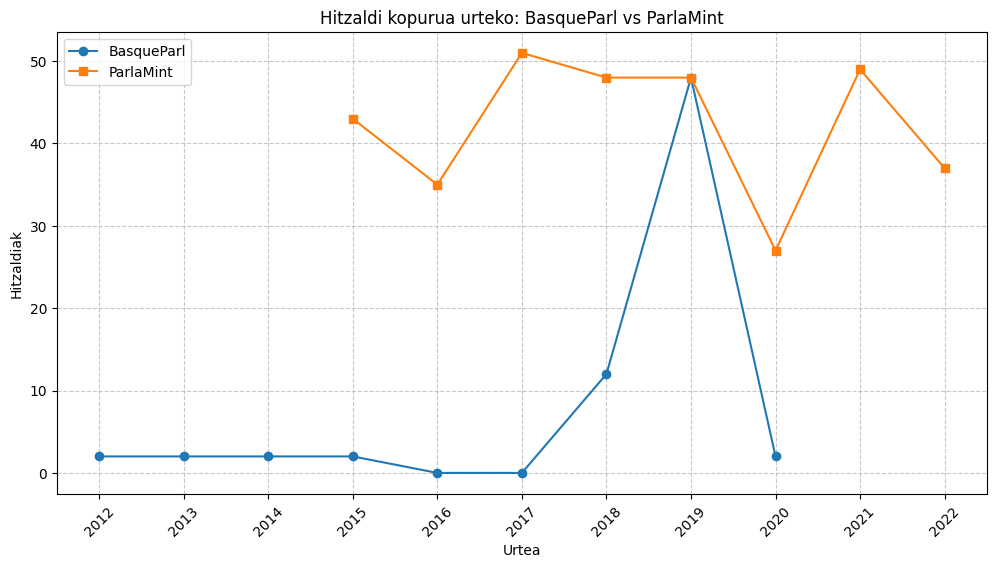

In [8]:
# Zenbat hitzaldi urtero
plt.figure(figsize=(12, 6))
plt.plot(df_basqueParl["Urtea"], df_basqueParl["Hitzaldiak"], marker='o', label="BasqueParl")
plt.plot(df_parlaMint["Urtea"], df_parlaMint["Hitzaldiak"], marker='s', label="ParlaMint")
plt.xlabel("Urtea")
plt.ylabel("Hitzaldiak")
plt.xticks(years, rotation=45)
plt.title("Hitzaldi kopurua urteko: BasqueParl vs ParlaMint")
plt.legend()
plt.grid(linestyle='--', alpha=0.7)
plt.show()



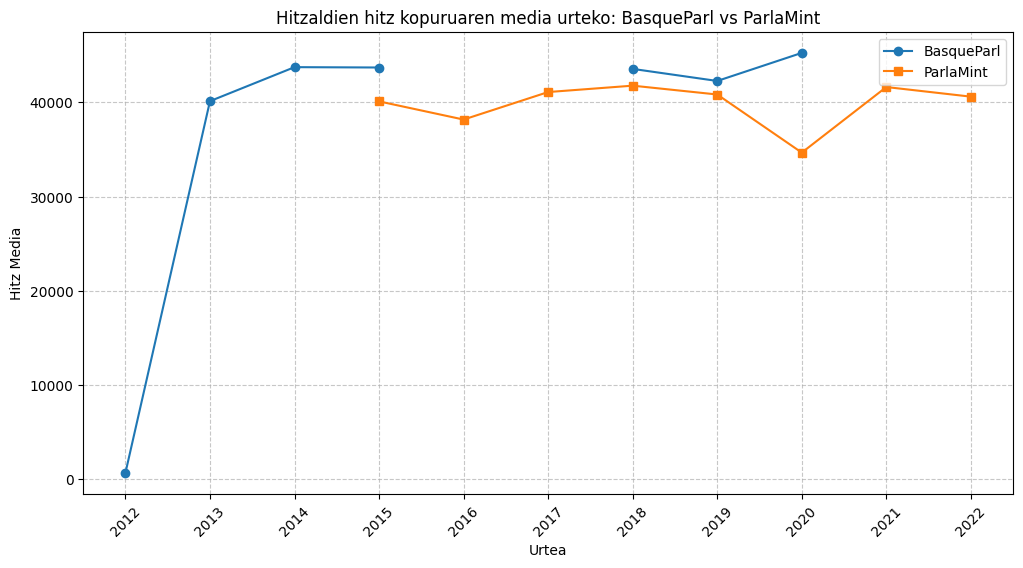

In [9]:
# Hitz media hitzaldiko urtero
plt.figure(figsize=(12, 6))
plt.plot(df_basqueParl["Urtea"], df_basqueParl["Hitz_Media"], marker='o', label="BasqueParl")
plt.plot(df_parlaMint["Urtea"], df_parlaMint["Hitz_Media"], marker='s', label="ParlaMint")
plt.xlabel("Urtea")
plt.ylabel("Hitz Media")
plt.xticks(years, rotation=45)
plt.title("Hitzaldien hitz kopuruaren media urteko: BasqueParl vs ParlaMint")
plt.legend()
plt.grid(linestyle='--', alpha=0.7)
plt.show()